# Processing the results

vertical VS horizontal evacuations

1. how many unsuccessful evacs by the end? -> box and whisker plot: v/h comparison per prep time
2. who is involved?
	1. same people every time? -> histogram of likelihood of individuals being trapped across different instantiations of a scenario
	2. relationship with age? -> ^ but overlaid different colours for different age groups
3. _where_ are the problems?
	1. home locations (of those who don't make it) -> take trapped persons; colour their homes by likelihood of trappage
	2. final location -> how many people are here VS how many times does this place show up per scenario? Bin locations of trapped persons, then groupby scenario. For each location, calculate likelihood (% of runs appearing) and num people present. Plot points where likelihood is > some amount, with size being likelihood and colour the number of people present.

and **how does this vary relative to changing prep time?** ==> repeat for each category of preparation time

## Handling raw result files

First, we'll read in the data from the file and do some minimal cleanup. Load the necessary tools.

In [1]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import matplotlib as mpl
import matplotlib.pyplot as plt
import os
from os.path import isfile, join
import pylab as plt
from glob import glob
import subprocess
import re
import math
from pathlib import Path

import geopandas
#from matplotlib_scalebar.scalebar import ScaleBar

from shapely import wkt

import seaborn as sns
from matplotlib.collections import LineCollection
import matplotlib.patches as mpatches
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

Now read in the data - including the spatial data involved with the creation of the simulation.

In [2]:
# set up the filenames!

rawDataDir = "/Users/swise/workspace/takamatsu/data/takamatsuTsunamiDemo/"
resultsDir = "/Users/swise/Projects/hitomi/data/vertEvac/"
total_sim_time = 60

Let's also read in the demographic information

In [195]:
synthPop = "synthPop_hh_1769409280626.txt"
indivInfo = {}
with open(rawDataDir + synthPop) as f:
    for line in f:
        elementsOfHh = line.strip().split("\t")
        for p in elementsOfHh[3:]:
            i_info = p.split(":")
            indivInfo[i_info[0]] = int(i_info[1])
indivs = pd.DataFrame(list(indivInfo.items()), columns=["id", "age"])

#### Testing if things are read in correctly

In [4]:
f_horiz = "out_params_default_txt_noVertEvac0.txt" # hard code it to be sure you get a proper example
f_vert  = "out_params_default_txt_vertEvac0.txt"
#f_roads = "out_params_default_txt_vertEvac0_roaduse_5.txt"

raw_data_horiz = pd.DataFrame(pd.read_csv(resultsDir + f_horiz, sep='\t')) # read in file
raw_data_vert = pd.DataFrame(pd.read_csv(resultsDir + f_vert, sep='\t')) # read in file
#raw_road_data = pd.DataFrame(pd.read_csv(workingDir + f_roads, sep='\t', header=None))

In [5]:
raw_data_vert.set_index("ID")
#raw_data_horiz.set_index("ID")

,age,status,evacuatingRecord,flooded,x_home,y_home,x_loc,y_loc,has_vehicle
ID,,,,,,,,,
-1406782737490618263,16,Home,NaN,notSubmerged,414396,3798018,414396,3798018,1
-6343473985754982838,17,Home,NaN,notSubmerged,414396,3798018,414396,3798018,0
5384495353871318227,1,Home,NaN,notSubmerged,414396,3798018,414396,3798018,0
2858753827684367568,13,Home,NaN,notSubmerged,415316,3795652,415316,3795652,1
931338415079244631,12,Home,NaN,notSubmerged,415316,3795652,415316,3795652,0
...,...,...,...,...,...,...,...,...,...
-6060685028866928173,5,Home,NaN,notSubmerged,408560,3797079,408560,3797079,1
-4887120893209099219,3,Home,NaN,notSubmerged,408560,3797079,408560,3797079,0
5217027716305325544,8,Trapped,"BEGIN_EVACUATING:0.0,EVAC_ORDER_PROMPTED_AT:0,...",inZone,413241,3800201,413241,3800201,1


### Extracting the evacuation times

Let's create a helper function to extract the relevant information from the raw records!

In [6]:
# helper function
def extractEvacTime(s, totalSteps):
    bits = s.split(',')
    record = {}
    for b in bits:
        try:
            k,v = b.split(':')
            if k[0] not in record:
                record[k] = float(v)
        except:
            pass

    if "FINISHED_PREP_START_EVACUATING" in record:
        startTime = record["FINISHED_PREP_START_EVACUATING"]
    elif "BEGIN_EVACUATING" in record:
        startTime = record["BEGIN_EVACUATING"]
    else:
        return -1
        
    finishTime = totalSteps

    if "FINISH_EVAC" in record:
        finishTime = record["FINISH_EVAC"]
    elif "ENTER_SHELTER" in record:
        finishTime = record["ENTER_SHELTER"]
    elif "DONE" in record:
        finishTime = record["DONE"]
    elif "TRAPPED" in record:
        finishTime = record["TRAPPED"]
        
    return finishTime - startTime

def getAllValidEvacs(df, total_sim_time):
    raw = [extractEvacTime(s, total_sim_time) for s in df["evacuatingRecord"]]
    a = np.array(raw)
    return a[a >= 0]

### Structuring the results data

Each instantiation is held in its own file. The filename contains information about:
* the input parameter file
* vertical or horizontal evacuation
* the preparation time

In this case, the input parameters are being held constant, so the data only needs to be structured into not/vertical and different preparation times. The logical thing to do is to create a dictionary for each, and to merge all of the input files into a single dataframe for each scenario.

I can do that by creating a list of dataframes and then merging it with pd.concat for each scenario.

In [7]:
def filenameToScenario(f):
    
    dimensions = "vert_" if "_vertEvac" in f else "hori_"
    
    prep_time = 30
    prep_time_index = f.find("min")
    if prep_time_index >= 0:
        
        prep_time = int(f[prep_time_index - 2: prep_time_index])
    return [prep_time, dimensions]

dummy = "out_params_default_txt_vertEvac_10min29.txt"
filenameToScenario(dummy)

[10, 'vert_']

### Reading in the files

In [9]:
directory_path = Path(resultsDir)
file_paths = directory_path.glob('*.txt')

results_by_scenario = {}
for f in file_paths:
    prep_time, dimensions = filenameToScenario(f.stem)
    
    instantiation = pd.read_csv(f, sep='\t').dropna(subset=["evacuatingRecord"]).assign(file_id=f.stem)
    instantiation["evacTime"] = [extractEvacTime(s, total_sim_time) for s in instantiation["evacuatingRecord"]]
    
    results_by_scenario.setdefault(dimensions, {}).setdefault(prep_time, []).append(instantiation)
    print(".", end='')

................................................................................................................................................................................................................................................

In [ ]:
combined_df = pd.concat(df_list, ignore_index=True)

Ok, go through the files and pull out the evacuating times.

## 1. how many unsuccessful evacs were there by the end of each scenario?

box and whisker plot: v/h comparison per prep time

In [53]:
#final_status_by_prep_time = {}
bulk_results_by_status = []

for dimension, r_by_dim in results_by_scenario.items():
    for prep_time, instances in r_by_dim.items():
        per_instance = []
        for instances in instances:
            per_instance.append(instances.groupby(["status"]).size())
        x = pd.concat(per_instance, axis=1).transpose().assign(prep_time=prep_time).assign(dimension=dimension)
        bulk_results_by_status.append(x)
#        final_status_by_prep_time.setdefault(dimension, {})[prep_time] = x

final_status_by_prep_time = pd.concat(bulk_results_by_status, ignore_index=True)


In [54]:
final_status_by_prep_time

status,Evacuated,Evacuating,Sheltering,Trapped,prep_time,dimension
0,18723,12218,2,70877,30,vert_
1,18511,12216,1,71092,30,vert_
2,19443,12599,1,69777,30,vert_
3,19600,12524,1,69695,30,vert_
4,19574,12713,1,69532,30,vert_
...,...,...,...,...,...,...
235,25658,14040,3,62119,20,hori_
236,25513,13982,1,62324,20,hori_
237,25893,13964,1,61962,20,hori_
238,26099,14202,1,61518,20,hori_


Ok, so now pull out the "trapped" option for each scenario; if we add the prep time as a column

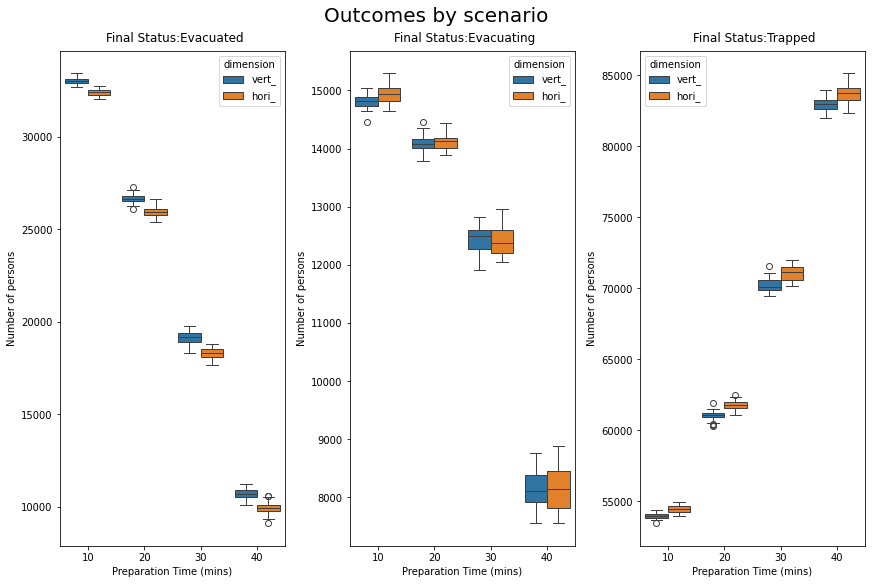

In [89]:
statuses_to_plot = ["Evacuated", "Evacuating", "Trapped"]
labels = {"_vert": "Vertical", "_horiz": "Horizontal"}
max_height_of_plot = 100000

fig = plt.figure(figsize=(12,8), layout="constrained")
subfigs = fig.subfigures(1, len(statuses_to_plot))

fig_index = 0

for status in statuses_to_plot:
    
    # create the new subfigure and its axis
    my_subfig = subfigs[fig_index]
    my_ax = my_subfig.subplots(1, 1)
    
    # create the boxplot and update its axes' labels
    sns.boxplot(data=final_status_by_prep_time, x="prep_time", y=status, hue="dimension", ax=my_ax)
    my_ax.set(xlabel="Preparation Time (mins)", ylabel="Number of persons")
    #my_ax.set_ylim(bottom=0, top=max_height_of_plot)
    my_subfig.suptitle("Final Status:" + status, x=0.6, ha="center")
    
#    my_ax.legend(labels = ['Vertical', 'Horizontal'], loc='center left')#, frameon=False)
    
    # increment the index
    fig_index += 1

# show the figure!
fig.suptitle("Outcomes by scenario", fontsize=20)
plt.savefig("scenario_outcomes_boxplot.png", dpi=300, bbox_inches="tight")
plt.show()



## 2. who is involved?

1. same people every time? -> histogram of likelihood of individuals being trapped across different instantiations of a scenario
2. relationship with age? -> ^ but overlaid different colours for different age groups

In [122]:
bulk_likelihoods_of_trapped = {}

for dimension, r_by_dim in results_by_scenario.items():
    
    likelihoods_per_prep_time = {}
    
    for prep_time, instances in r_by_dim.items():
        
        # create a new holder
        trappedThisScenario = pd.Series(dtype=int)
        
        # assemble a list of all IDs of individuals who were trapped at the end
        for instance in instances:
            trappedThisScenario = pd.concat([trappedThisScenario, instance[instance["status"] == "Trapped"]["ID"]])
      
        # calculate the likelihood for each person in this scenario and store it
        numInstances = float(len(instances))
        likelihoods = trappedThisScenario.value_counts() / numInstances
        likelihoods_per_prep_time[prep_time] = likelihoods
        
    # store the results for all the scenarios with this dimension
    bulk_likelihoods_of_trapped[dimension] = likelihoods_per_prep_time

In [164]:
from matplotlib.lines import Line2D

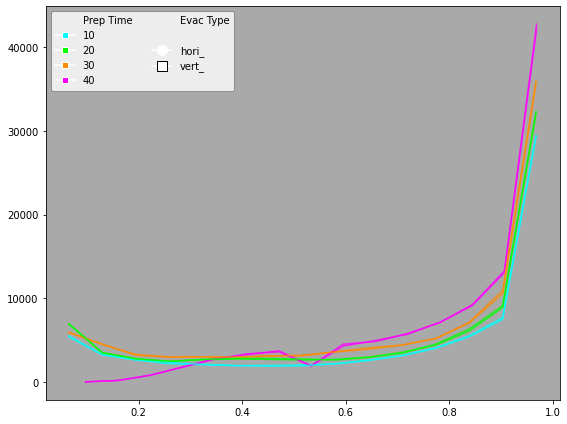

In [177]:
# Create a figure and axis using subplots
fig, ax = plt.subplots(figsize=(8, 6))

colourPerPrepTime = {10: 'cyan', 20: 'lime', 30: 'darkorange', 40: 'magenta'}
outlinePerDimension = {"hori_": 'white', "vert_": 'black'}
markerPerDimension = {"hori_": 'o', "vert_": 's'}

# Plot histograms with transparency using the 'alpha' parameter
# 'edgecolor' helps distinguish the individual bars when they overlap
for dimension, all_prep_times in bulk_likelihoods_of_trapped.items():
    for prep_time, likelihoods in all_prep_times.items():
        
        counts, bin_edges = np.histogram(likelihoods, bins=15)
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
        
        ax.plot(bin_centers, counts, label=dimension + str(prep_time), #linestyle='None',
                #marker=markerPerDimension[dimension],  
                color=colourPerPrepTime[prep_time], 
                #markersize=10, #prep_time/2, 
                #markeredgecolor=outlinePerDimension[dimension],   # This sets the border color to black
                #markeredgewidth= 2,
                alpha=0.8)
        
# Add titles, labels, and a legend
#ax.set_title('Transparent Overlapping Histograms', fontsize=14)
#ax.set_xlabel('Value', fontsize=12)
#ax.set_ylabel('Frequency', fontsize=12)


color_handles = [ Line2D([0], [0], marker='s', color='w', 
                         markerfacecolor=colourPerPrepTime[prep_time], label=str(prep_time)) for prep_time in colourPerPrepTime]
shape_handles = [ Line2D([0], [0], marker=markerPerDimension[dimension], color='w', 
                         markerfacecolor='w', markeredgecolor=outlinePerDimension[dimension], markersize=10, label=dimension) for dimension in markerPerDimension]

header_prep_time = Line2D([], [], color='none', label='Prep Time')
header_dimension = Line2D([], [], color='none', label='Evac Type')
empty_header_for_spacing = Line2D([], [], color='none', label='')

all_handles = [header_prep_time] + color_handles + [header_dimension, empty_header_for_spacing] + shape_handles + [empty_header_for_spacing]
all_labels = [h.get_label() for h in all_handles]

ax.legend(
    handles=all_handles,
    labels=all_labels,
    loc='upper left',
    fontsize=10,
    frameon=True,
    facecolor='white',
    edgecolor='gray',
    ncol=2
)

#ax.legend(loc='upper left', ncol=2, markerscale=.5, fontsize=12)
ax.set_facecolor('darkgray')

#plt.yscale('log')

# Adjust layout to make sure everything fits nicely
plt.tight_layout()

# Display or save the plot
#plt.savefig('transparent_histograms.png', facecolor=fig.get_facecolor())
plt.show()



,index,0,my_key,age
0,4862367198694900921,1.000000,4862367198694900921,9
1,-6115807838896422114,1.000000,-6115807838896422114,17
2,2035721599439710171,1.000000,2035721599439710171,11
3,-746446509447473639,1.000000,-746446509447473639,16
4,2172501845960263038,1.000000,2172501845960263038,10
...,...,...,...,...
88095,-8613958006884486775,0.033333,-8613958006884486775,12
88096,7348903950413981178,0.033333,7348903950413981178,11
88097,961701124132151408,0.033333,961701124132151408,1
88098,3217105143639348412,0.033333,3217105143639348412,5


In [218]:
for x in indiv_likes.groupby(["age"])[0]:
    print(x)

(0, 12       1.000000
41       1.000000
45       1.000000
51       1.000000
60       1.000000
           ...   
87832    0.033333
87833    0.033333
87941    0.033333
87977    0.033333
88031    0.033333
Name: 0, Length: 3839, dtype: float64)
(1, 27       1.000000
30       1.000000
32       1.000000
50       1.000000
53       1.000000
           ...   
87979    0.033333
88003    0.033333
88030    0.033333
88050    0.033333
88097    0.033333
Name: 0, Length: 4347, dtype: float64)
(2, 5        1.000000
6        1.000000
8        1.000000
42       1.000000
49       1.000000
           ...   
87932    0.033333
87992    0.033333
88043    0.033333
88048    0.033333
88071    0.033333
Name: 0, Length: 4379, dtype: float64)
(3, 72       1.000000
91       1.000000
107      1.000000
217      1.000000
352      1.000000
           ...   
88024    0.033333
88034    0.033333
88042    0.033333
88077    0.033333
88082    0.033333
Name: 0, Length: 4234, dtype: float64)
(4, 18       1.000000
74       1.000

<ipython-input-216-ce4b3189960e>:45: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


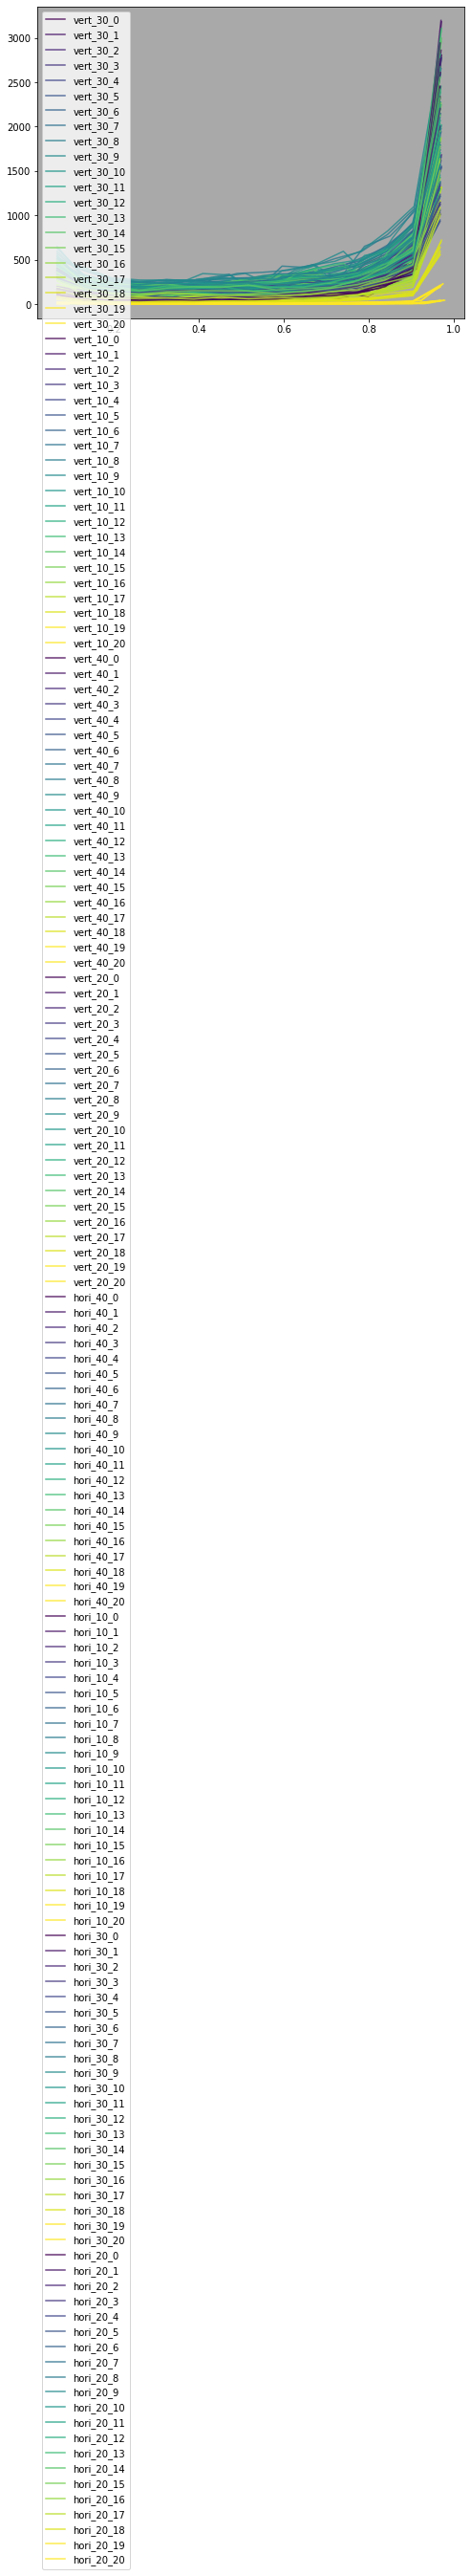

In [216]:
# Create a figure and axis using subplots
fig, ax = plt.subplots(figsize=(8, 6))

#colourPerAge = {10: 'cyan', 20: 'lime', 30: 'darkorange', 40: 'magenta'}
outlinePerDimension = {"hori_": 'white', "vert_": 'black'}
markerPerDimension = {"hori_": 'o', "vert_": 's'}

coloredByAge = mpl.colormaps['viridis'].resampled(20)

# Plot histograms with transparency using the 'alpha' parameter
# 'edgecolor' helps distinguish the individual bars when they overlap
for dimension, all_prep_times in bulk_likelihoods_of_trapped.items():
    for prep_time, likelihoods in all_prep_times.items():
        
        likes = pd.DataFrame(likelihoods).reset_index()
        likes["my_key"] = [str(key) for key in likes["index"]]
        indiv_likes = likes.join(indivs.set_index("id"), on="my_key")

        by_age_group = indiv_likes.groupby(["age"])[0]
        for age, group in by_age_group:
            counts, bin_edges = np.histogram(group, bins=15)
            bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

            ax.plot(bin_centers, counts, label=dimension + str(prep_time)+ "_" + str(age), #linestyle='None',
                    #marker=markerPerDimension[dimension],  
                    color=coloredByAge(age),#colourPerAge[age], 
                    #markersize=10, #prep_time/2, 
                    #markeredgecolor=outlinePerDimension[dimension],   # This sets the border color to black
                    #markeredgewidth= 2,
                    alpha=0.8)
        
# Add titles, labels, and a legend
#ax.set_title('Transparent Overlapping Histograms', fontsize=14)
#ax.set_xlabel('Value', fontsize=12)
#ax.set_ylabel('Frequency', fontsize=12)

ax.legend()

#ax.legend(loc='upper left', ncol=2, markerscale=.5, fontsize=12)
ax.set_facecolor('darkgray')

#plt.yscale('log')

# Adjust layout to make sure everything fits nicely
plt.tight_layout()

# Display or save the plot
#plt.savefig('transparent_histograms.png', facecolor=fig.get_facecolor())
plt.show()



## 3. _where_ are the problems?
1. home locations (of those who don't make it) -> take trapped persons; colour their homes by likelihood of trappage
2. final location -> how many people are here VS how many times does this place show up per scenario? Bin locations of trapped persons, then groupby scenario. For each location, calculate likelihood (% of runs appearing) and num people present. Plot points where likelihood is > some amount, with size being likelihood and colour the number of people present.

### Spatial data

In [ ]:
waterFloodedFile = rawDataDir + "flooded_reproj.shp"
roadsFile = rawDataDir + "roads_simple.shp"
shelterFile = rawDataDir + "sheltersWithParking.shp"
#stationsFile = rawDataDir + "trainStationsWithPassengers.shp"

# read in the list of files from the directory

workingDir = procDataDir
files = os.listdir(workingDir)
holder = {} # set up the holder

roads = geopandas.read_file(roadsFile)
water = geopandas.read_file(waterFloodedFile)
shelters = geopandas.read_file(shelterFile)
#stations = geopandas.read_file(stationsFile)

# ARCHIVE: Analysing the data

We'll want to get a general sense of the data before drilling down further

In [ ]:
fig = plt.figure(figsize=(12,8), layout="constrained")
subfigs = fig.subfigures(1, len(my_scenarios))

fig_index = 0
for title in my_scenarios:
    
    # create the new subfigure and its axis
    my_subfig = subfigs[fig_index]
    my_ax = my_subfig.subplots(1, 1)
    
    # create a dataset to hold this specific feature
    counts = pd.DataFrame({"count": my_scenarios[title], "preptime": prep_times, "scenario": scenario_names, "vertical": vertical})

    # create the boxplot and update its axes' labels
    sns.boxplot(data=counts, x="preptime", y="count", hue="vertical", ax=my_ax)
    my_ax.set(xlabel="Preparation Time (mins)", ylabel="Number of persons")
    my_subfig.suptitle(title, x=0.6, ha="center")
    
    # increment the index
    fig_index += 1

# show the figure!
fig.suptitle("Outcomes by scenario", fontsize=20)
plt.savefig("scenario_outcomes_boxplot.png", dpi=300, bbox_inches="tight")
plt.show()



Basic comparison: let's compare the average values for each of these outcomes for each given scenario

## Merging the different scenarios

Let's merge all of the scenario results so we can compare like-to-like

Again, we're going to test first - this refers to the SINGLE INSTANCE referenced above

In [ ]:
combined_records = raw_data_vert.join(raw_data_horiz, lsuffix="_vert", rsuffix="_horiz")
#combined_records = combined_records[combined_records["evacuatingRecord_horiz"].notna()]

combined_records.head()

In [ ]:
evac_records = combined_records[combined_records["status_horiz"] != "Home"]
evac_records = evac_records[evac_records["status_horiz"] != "Sheltering"]
evac_records.head()

Let's also pull out the ones that had differing outcomes

In [ ]:
differingOutcomes = combined_records[combined_records["status_vert"] != combined_records["status_horiz"]]
differingOutcomes.head()

Finally, we're going to add an extra column to the situations where the outcome differs so we can see how these vary

In [ ]:
change_in_status_by_type = differingOutcomes["status_horiz"] + "->" + differingOutcomes["status_vert"]
differingOutcomes["status_outcome_difference"] = change_in_status_by_type

In [ ]:
#differingOutcomes.groupby(["status_horiz", "status_vert"])["ID_horiz"].count()
outcomes.index

In [ ]:
from matplotlib.colors import LogNorm, Normalize, PowerNorm

outcomes = evac_records.groupby(["status_horiz", "status_vert"])["ID_horiz"].count().reset_index(name='count')
pivoted_out = outcomes.pivot(index="status_horiz", columns="status_vert", values="count")

fig, ax = plt.subplots(figsize=(10, 10))

sns.set(font_scale=1.25)
sns.heatmap(pivoted_out, annot=True, ax=ax, fmt="d", norm=PowerNorm(gamma=0.5))#, cbar=False, )
ax.xaxis.tick_top()
ax.xaxis.set_label_position("top")

plt.title('Evacuation Outcomes by Scenario')
plt.show()

### Extracting evacuation information

Does it work? Let's try it on one example.

some work here with `.reset_index()` and `.get(1)` but no longer used

In [ ]:
differingOutcomes["evacuatingRecord_horiz"].get(40)

In [ ]:
differingOutcomes["evacuatingRecord_vert"].get(40)

In [ ]:
raw_road_data = raw_road_data.rename(columns={0: "roads", 1: "usage"})

#raw_road_data.columns
raw_road_data["usage"] = [np.fromstring(x[1:-1], dtype=int, sep=', ') for x in raw_road_data["usage"]]

record_time_step = int(f_roads.split('_')[-1].replace(".txt", ""))

# how many steps were recorded - based on how frequently the roads were checked
total_sim_time = len(raw_road_data["usage"][0]) * record_time_step


In [ ]:
evacuees = raw_data[raw_data["status"] == "Evacuated"].reset_index()
example = getAllValidEvacs(evacuees, total_sim_time)

In [ ]:
evacuees["evacuatingRecord"].get(0)

In [ ]:
example

In [ ]:
takeAllValues = pd.array([extractEvacTime(x, total_sim_time) for x in evacuees["evacuatingRecord"]])
shortEvacs = evacuees[takeAllValues < 15]
records = shortEvacs["evacuatingRecord"]

In [ ]:
print(f)
records.get(19)

In [ ]:
shortEvacs["evacuatingRecord"].get(shortEvacs.index[0])

In [ ]:
evacuees["evacuatingRecord"].get(evacuees.index[0])

In [ ]:
x = [extractEvacTime(x, total_sim_time) for x in evacuees["evacuatingRecord"]]
x

In [ ]:
evacuees = raw_data[raw_data["status"] == "Evacuated"].reset_index()
evacTime_evacuated = getAllValidEvacs(evacuees, total_sim_time)

still_evacuating = raw_data[raw_data["status"] == "Evacuating"].reset_index()
evacTime_evacuating = getAllValidEvacs(evacuees, total_sim_time)

#trapped = raw_data[raw_data["status"] == "Evacuating"].reset_index()


What does an evacuation record look like, just as an example?

In [ ]:
evacuaters = raw_data[raw_data["evacuatingRecord"].notna()]
e = evacuaters["evacuatingRecord"]
e.get(e.index[0])

In [ ]:
pd.unique(raw_data["flooded"])

In [ ]:
pd.unique(raw_data.status)

In [ ]:
vertical

### Trapped

In [ ]:
trappedCounts_vert = pd.Series(numTrapped)[vertical]
nonverts = [not x for x in vertical]
trappedCounts_nonVert = pd.Series(numTrapped)[nonverts]

fig, ax = plt.subplots(ncols=1, nrows = 1, sharex=True, sharey=True, figsize=(15,10))
ax.hist(trappedCounts_vert, color='red', label="Vertical evac enabled", alpha=.5)
ax.hist(trappedCounts_nonVert, color='blue', label="Horizontal evac only", alpha=.5)
ax.legend()
ax.set_title("Number of persons caught in the first wave")
ax.set_xlabel("Number of persons")
ax.set_ylabel("Frequency of outcome (number of simulation runs)")

trappedFilename = "trappedDist.png"
plt.savefig(trappedFilename, format="png", dpi=720)


### Vertical Evacuation - Times

In [ ]:
# pull out the noVert and vertEvac separately; make two plots and, for each instance, plot them on either side for journey times
#vertEvac = [not "_vertEvac" in f for f in files]
colors = ["red", "blue"]

# two graph version
fig, ax = plt.subplots(ncols=1, nrows = 1, sharex=True, sharey=True, figsize=(15,10))
xbins = np.arange(0, 40, 2)
for index, val in enumerate(evacueeFullData):
    myAxis = 1
    if(vertical[index]):
        myAxis = 0        
    ax.hist(val, bins=xbins, alpha=.3, color=colors[myAxis])

ax.set_title("Evacuation journey duration")
ax.set_xlabel("journey time (minutes)")
ax.set_ylabel("number of evaucees")

vert_patch = mpatches.Patch(color='red', label='Vertical')
horiz_patch = mpatches.Patch(color='blue', label='Horizontal only')

ax.legend(handles=[vert_patch, horiz_patch])

journeyDurationComparisonFilename = "journeyDurationComparison.png"
plt.savefig(journeyDurationComparisonFilename, format="png", dpi=720)

In [ ]:
# pull out the noVert and vertEvac separately; make two plots and, for each instance, plot them on either side for journey times
#vertEvac = [not "_vertEvac" in f for f in files]
colors = ["red", "blue"]

# two graph version
fig, axs = plt.subplots(ncols=2, nrows = 1, sharex=True, sharey=True, figsize=(15,10))
xbins = np.arange(0, 65, 5)
for index, val in enumerate(evacueeFullData):
    myAxis = 1
    if(vertical[index]):
        myAxis = 0        
    axs[myAxis].hist(val, bins=xbins, alpha=.3, color=colors[myAxis])
    ax.hist(val, bins=xbins, alpha=.3, color=colors[myAxis])

axs[0].set_title("Vertical Evacuation")
axs[1].set_title("No Vertical Evacuation")
for ax in axs:
    ax.set_xlabel("journey time (minutes)")
axs[0].set_ylabel("number of evaucees")

### By Attribute

Make it possible to extract by attributes

In [ ]:
def selectOnAttribute(df, targetValues, waterFile = None, exclude=False):
    
    myDf = df
    
    # select on the flooding scenario?
    if waterFile is not None:
        # pull out the runs on a specific water setting
        myDf = df[df["waterShapefile"] == waterFile]

    # make sure there's actually something to select!
    if len(targetValues) == 0:
        return myDf
        
    # iterate through, selecting on these
    for i, j in targetValues.items():
        
        if exclude:
            myDf = myDf[~myDf[i].isin(j)]
            
        else:
            myDf = myDf[myDf[i].isin(j)]            

    return myDf

In [ ]:
df = evacuaters
roadsFilename = roadsFile
waterFilename = waterFloodedFile
xcolname = 'x_loc'
ycolname = 'y_loc'

# select on appropriate atts
# transform this into spatial data
gdf = geopandas.GeoDataFrame(df, geometry=geopandas.points_from_xy(
    df[xcolname], df[ycolname]))
shelters_gdf = geopandas.GeoDataFrame(shelters, geometry=geopandas.points_from_xy(
    shelters["entranceX"], shelters["entranceY"]))

# aggregate by the final statuses
peopleInZone = gdf.groupby(['status'])#.agg({'ID': 'count'}).reset_index()

# initialise for the mapping phase
roads = geopandas.read_file(roadsFilename)
water = geopandas.read_file(waterFilename)
#shelters = geopandas.read_file(shelters)

In [ ]:
type(trappedFullData)

In [ ]:
# precomputables
roadsFilename = roadsFile
waterFilename = waterFloodedFile
xcolname = 'x_loc'
ycolname = 'y_loc'

shelters_gdf = geopandas.GeoDataFrame(shelters, geometry=geopandas.points_from_xy(
    shelters["entranceX"], shelters["entranceY"]))

# initialise for the mapping phase
roads = geopandas.read_file(roadsFilename)
water = geopandas.read_file(waterFilename)

# confirm CRS
layers = [roads, water, shelters_gdf]
for l in layers:
    l.set_crs(epsg=6690)

# gdfs
gdfs = []

for index, val in enumerate(evacueeFullData):
    print(val)
    gdf = geopandas.GeoDataFrame(val, geometry=geopandas.points_from_xy(val[xcolname], val[ycolname]))
    gdf.set_crs(epsg=6690)
    gdfs.append(gdf)

In [ ]:
gdf.plot(color=colors[myAxis], zorder=3, marker='o', markersize=15, alpha=.003)

In [ ]:
colors = ["red", "blue"]

# set up the figure
fig, base = plt.subplots(figsize=(20, 15))

# plot the background
roads.plot(ax=base, edgecolor='#999999')
water.plot(ax=base, color='#AACCFF')
shelters_gdf.plot(ax=base, zorder=2, markersize=100, color="yellow")

for index, gdf in enumerate(gdfs):
    myAxis = 1
    if(vertical[index]):
        myAxis = 0
    gdf.plot(ax=base, color=colors[myAxis], zorder=3, marker='o', markersize=15, alpha=.005)
    
xmin, ymin, xmax, ymax = gdf.total_bounds
pad = 15  # add a padding around the geometry
base.set_xlim(xmin-pad, xmax+pad)
base.set_ylim(ymin-pad, ymax+pad)

vert_patch = mpatches.Patch(color='red', label='Vertical')
horiz_patch = mpatches.Patch(color='blue', label='Horizontal only')

base.legend(handles=[vert_patch, horiz_patch])

finalTrappedLocsFilename = "finalTrappedLocations_both.png"
plt.savefig(finalTrappedLocsFilename, format="png", dpi=720)

In [ ]:
len(trappedFullData)

In [ ]:
# plot the background and the people

layers = [roads, water, shelters_gdf, gdf]
for l in layers:
    l.set_crs(epsg=6690)

fig, base = plt.subplots(figsize=(20, 15))

roads.plot(ax=base, edgecolor='#999999', alpha = .4)
water.plot(ax=base, color='#AACCFF')
shelters_gdf.plot(ax=base, alpha = .3, zorder=2, markersize=100, color="yellow")
gdf.plot(ax=base, column="flooded", cmap="prism", legend=True, zorder=3, marker='o', markersize=15, alpha=.3)

xmin, ymin, xmax, ymax = shelters_gdf.total_bounds
pad = 15  # add a padding around the geometry
base.set_xlim(xmin-pad, xmax+pad)
base.set_ylim(ymin-pad, ymax+pad)


In [ ]:
evacuaters

In [ ]:
from geopandas import GeoSeries
from shapely.geometry import LineString
from matplotlib.colors import TwoSlopeNorm

# plot the journey information
feats = []
time = []
for g in gdf.itertuples():
    j = LineString([[g.x_home, g.y_home], [g.x_loc, g.y_loc]])
    feats.append(j)
    time.append(extractEvacTime(g.evacuatingRecord, total_sim_time))
journeys = geopandas.GeoDataFrame(geometry=GeoSeries(feats))

#time /= np.max(time)
journeys["evacTime"] = time


In [ ]:
layers = [roads, water, shelters_gdf, gdf, journeys]
for l in layers:
    l.set_crs(epsg=6690)

In [ ]:
hist, bins = np.histogram(journeys['evacTime'])

In [ ]:
[journeys["evacTime"] < 20]

In [ ]:
print(journeys.type)
print(gdf.type)

In [ ]:
gdf.iloc[-1]["evacuatingRecord"]

In [ ]:
vmin, vmax, vcenter = journeys.evacTime.min(), journeys.evacTime.max(), journeys.evacTime.mean()
norm = TwoSlopeNorm(vmin=vmin, vcenter=vcenter, vmax=vmax)
# create a normalized colorbar
cmap = 'plasma'
cbar = plt.cm.ScalarMappable(norm=norm, cmap=cmap)

In [ ]:
fig, base = plt.subplots(figsize=(20, 15))

roads.plot(ax=base, edgecolor='#999999', alpha = .4, zorder=-2)
water.plot(ax=base, color='#AACCFF', zorder=-3)
shelters_gdf.plot(ax=base, alpha = .3, zorder=2, markersize=100, color="yellow")
gdf.plot(ax=base, legend=True, zorder=3, marker='o', markersize=5, alpha=.05, color='black')##column="flooded", cmap='plasma', )
journeys.plot(ax=base, column="evacTime", zorder=1, linewidth=.5, cmap=cmap, norm=norm, legend=False, alpha=journeys["evacTime"]/vmax)
fig.colorbar(cbar)

xmin, ymin, xmax, ymax = gdf.total_bounds
pad = 15  # add a padding around the geometry
base.set_xlim(xmin-pad, xmax+pad)
base.set_ylim(ymin-pad, ymax+pad)


30 minutes milling around time!

1. journey duration histogram (successful)
2. final location of unsuccessful individuals (+ journey times?)
3. basic info: number of agents

In [ ]:
import random
import numpy as np
import math

def r_func(sigma):
    return sigma * math.sqrt(-2 * np.log(random.random()))


In [ ]:
fig, base = plt.subplots(figsize=(20, 15))
size = 1000
for sig in [1, 2, 4, 8, 10]:
    sample = [30 + r_func(sig) for i in range(size)]
    base.hist(sample, alpha = .3, label=sig)#, cumulative=1, density=True, histtype="step")

base.legend()

### Sheltering in place (badly)

In [ ]:
sns.set_style('white')

exportMapByScenario(holder, "hicss_stillEvacuating_flooded.png", "Unfinished Evacuation Locations", waterFloodedFile, roadsFile, includeAtts ={'status': ['Evacuating']})

Customising label legends: [here](https://stackoverflow.com/questions/74143732/customize-legend-labels-in-geopandas)
MatPlotLib [histogram documentation](https://matplotlib.org/stable/gallery/statistics/histogram_normalization.html)

Changing the markersize?
` cities.plot(markersize=cities['values']) `

[Projection info](https://www.practicaldatascience.org/notebooks/gis/50_gis_crs_geopandas.html) and [working with spatial data](https://earthdatascience.org/courses/earth-analytics-python/spatial-data-vector-shapefiles/python-change-spatial-extent-of-map-matplotlib-geopandas/)
